In [31]:
import pandas as pd
import time
import os
from dotenv import load_dotenv
import json
import requests
import re

In [24]:
load_dotenv()

api_key = os.getenv("API_KEY")

In [5]:
df = pd.read_csv("cleaned_product_reviews.csv", encoding="utf-8")
df

,days,content,cleaned_review
0,240,Good phone in this price range,good phone in this price range
1,240,Nice product 🥰🥰🥰,nice product
2,180,Mobile looks extremely good and premium. Camer...,mobile looks extremely good and premium camera...
3,270,Good camera overall good phone,good camera overall good phone
4,240,Nice phone,nice phone
...,...,...,...
1740,240,Super camera,super camera
1741,240,Gud,gud
1742,240,"good phone looks premium on hand, it's not for...",good phone looks premium on hand it s not for ...
1743,240,Excellent mobile and smart looking and smart w...,excellent mobile and smart looking and smart w...


In [ ]:
def create_structured_chunks(df, max_words=750):
    chunks = []
    current_chunk = []
    current_word_count = 0
    
    for index, row in df.iterrows():
        # Format the metadata and the review text
        structured_review = f"{index+1}: [{row['days']} days ago] - {row['cleaned_review']}."
        
        # Count words in this specific structured review
        review_word_count = len(structured_review.split())
        
        # Check if adding this review exceeds our limit
        if current_word_count + review_word_count > max_words and current_chunk:
            # Join the current bucket into one string and save it
            chunks.append("\n".join(current_chunk))
            # Reset for the next chunk
            current_chunk = [structured_review]
            current_word_count = review_word_count
        else:
            # Add to the current bucket
            current_chunk.append(structured_review)
            current_word_count += review_word_count
            
    if current_chunk:
        chunks.append("\n".join(current_chunk))
        
    return chunks


In [11]:
final_chunks = create_structured_chunks(df, 600)

In [12]:
len(final_chunks)

43

In [16]:
final_chunks[42]

'1733: [240 days ago] - i love it.\n1734: [240 days ago] - good working and good looking.\n1735: [240 days ago] - good looking phone and oly one think minus please improve the processor otherwise this phone is normal usage person fine for them.\n1736: [240 days ago] - phone camera poor quality and observed overheating.\n1737: [240 days ago] - value for money best phone.\n1738: [240 days ago] - voice interrupted during calls microphone is not good after 6 month of use this phone is worse for calling microphone is worse don t buy this buy iqoo instead.\n1739: [240 days ago] - decent mobile at much better price.\n1740: [240 days ago] - very nice cemra.\n1741: [240 days ago] - super camera.\n1742: [240 days ago] - gud.\n1743: [240 days ago] - good phone looks premium on hand it s not for gaming but daily needs there is slight lag on overall ui but trust me display at this price is unbeatable battery back is 2 days and doesn t require t.\n1744: [240 days ago] - excellent mobile and smart lo

In [ ]:
all_results = []
url = "https://openrouter.ai/api/v1/chat/completions"


for i, chunk in enumerate(final_chunks):
    print(f"Processing chunk {i+1}/{len(final_chunks)}...")
    prompt = f"""
    Analyze these reviews individually. Format your response EXACTLY like this for every review (one per line):
    ID: X | Sentiment: [Pos/Neg] | Summary: [Text]
    
    Reviews:
    {chunk}

    Return exactly one line for every 'Review X' listed above. Do not skip any.
    """

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "HTTP-Referer": "http://localhost"  
    }

    data = {
        "model": "google/gemini-2.0-flash-001",
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 2000,
        "temperature": 0.1
    }

    try:
        response = requests.post(url, headers=headers, json=data)
        if response.status_code != 200:
            print(f"Server Error: {response.status_code} - {response.text}")
            continue
        
        result_json = response.json()
 
        if 'choices' in result_json:
            response_text = result_json['choices'][0]['message']['content']
            
            # Split by newline and filter out empty lines
            lines = [line.strip() for line in response_text.strip().split('\n') if line.strip()]
            all_results.extend(lines)
            print(f"Successfully processed {len(lines)} reviews in this chunk.")
        else:
            print(f"Error: 'choices' not found in response: {result_json}")
        
    except Exception as e:
        print(f"Error in chunk {i+1}: {e}")
        continue

    # Rate Limit Protection
    time.sleep(10)
print(f"Finished! Total lines collected: {len(all_results)}")

Processing chunk 1/43...
Successfully processed 29 reviews in this chunk.
Processing chunk 2/43...
Successfully processed 25 reviews in this chunk.
Processing chunk 3/43...
Successfully processed 28 reviews in this chunk.
Processing chunk 4/43...
Successfully processed 30 reviews in this chunk.
Processing chunk 5/43...
Successfully processed 26 reviews in this chunk.
Processing chunk 6/43...
Successfully processed 32 reviews in this chunk.
Processing chunk 7/43...
Successfully processed 23 reviews in this chunk.
Processing chunk 8/43...
Successfully processed 24 reviews in this chunk.
Processing chunk 9/43...
Successfully processed 25 reviews in this chunk.
Processing chunk 10/43...
Successfully processed 35 reviews in this chunk.
Processing chunk 11/43...
Successfully processed 31 reviews in this chunk.
Processing chunk 12/43...
Successfully processed 32 reviews in this chunk.
Processing chunk 13/43...
Successfully processed 38 reviews in this chunk.
Processing chunk 14/43...
Successf

In [ ]:
if len(all_results) == len(df):
    df['llm_output'] = all_results 
    df.to_csv("analyzed_reviews.csv", index=False)
    print("Success! Data saved.")
else:
    print(f"Mismatch! DF has {len(df)} rows, but LLM returned {len(all_results)} lines.")

Success! Data saved.


In [ ]:
df = pd.read_csv("analyzed_reviews.csv")

# Check for missing values in the new column
missing_count = df['llm_output'].isnull().sum()
if missing_count > 0:
    print(f"Alert: {missing_count} reviews do not have an LLM output.")
else:
    print("Perfect: All rows have LLM processing.")

Perfect: All rows have LLM processing.


In [ ]:
# Function to extract parts from the string
def extract_llm_data(text):
    if pd.isna(text): return None, None, None
    # Regex to find: ID: [num] | Sentiment: [text] | Summary: [text]
    pattern = r"ID:\s*(\d+)\s*\|\s*Sentiment:\s*(.*?)\s*\|\s*Summary:\s*(.*)"
    match = re.search(pattern, str(text))
    if match:
        return match.group(1), match.group(2), match.group(3)
    return None, None, None

df[['review_id', 'sentiment', 'summary']] = df['llm_output'].apply(
    lambda x: pd.Series(extract_llm_data(x))
)

df_final = df.drop(columns=['llm_output','cleaned_review','review_id'])

In [35]:
df_final

,days,content,sentiment,summary
0,240,Good phone in this price range,Pos,Good phone in this price range.
1,240,Nice product 🥰🥰🥰,Pos,Nice product.
2,180,Mobile looks extremely good and premium. Camer...,Neg,"Good looking phone with exceptional camera, bu..."
3,270,Good camera overall good phone,Pos,Good camera and overall good phone.
4,240,Nice phone,Pos,Nice phone.
...,...,...,...,...
1740,240,Super camera,Pos,Super camera.
1741,240,Gud,Pos,Good.
1742,240,"good phone looks premium on hand, it's not for...",Pos,"Good phone, premium look, not for gaming, slig..."
1743,240,Excellent mobile and smart looking and smart w...,Pos,"Excellent mobile, smart looking and working."


In [37]:
df_final.to_csv("final_analyzed_reviews.csv", index=False)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17468\2232109143.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=ax[1], palette=colors)


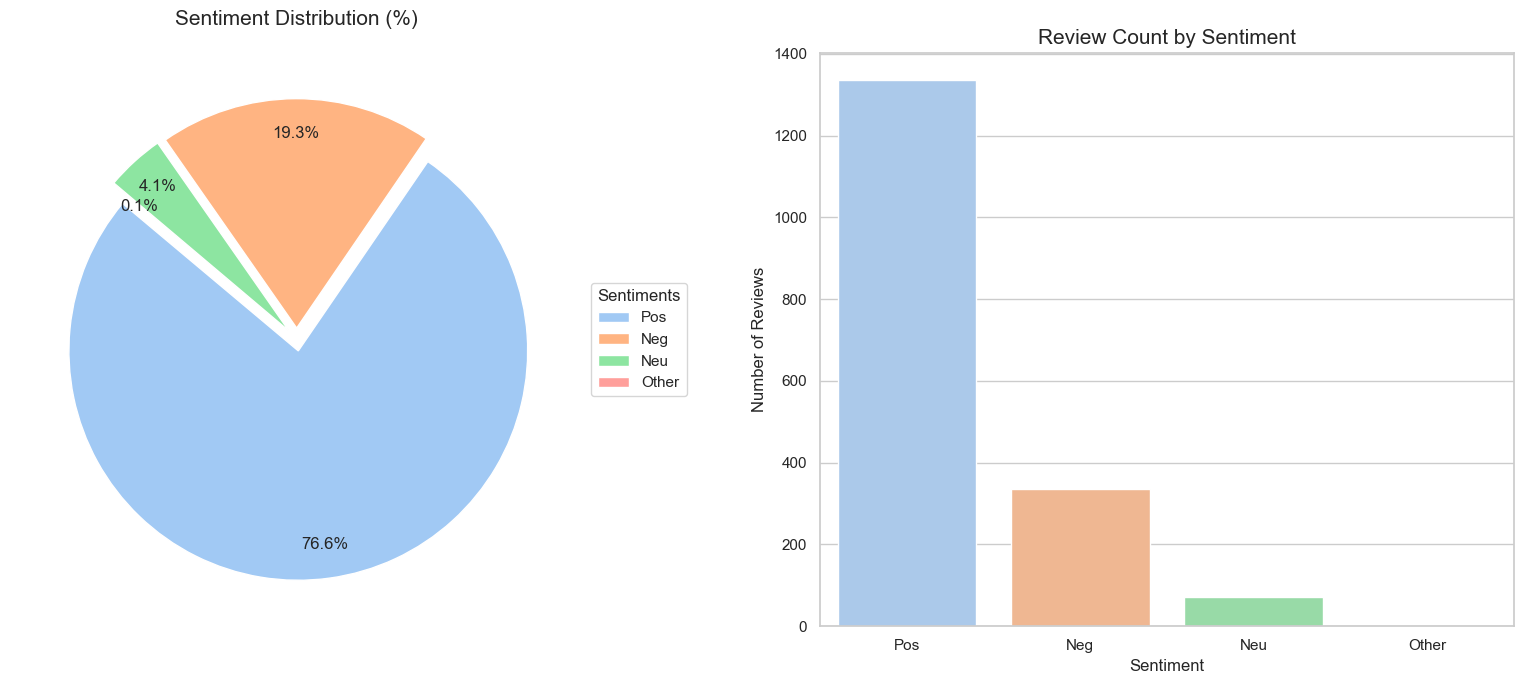

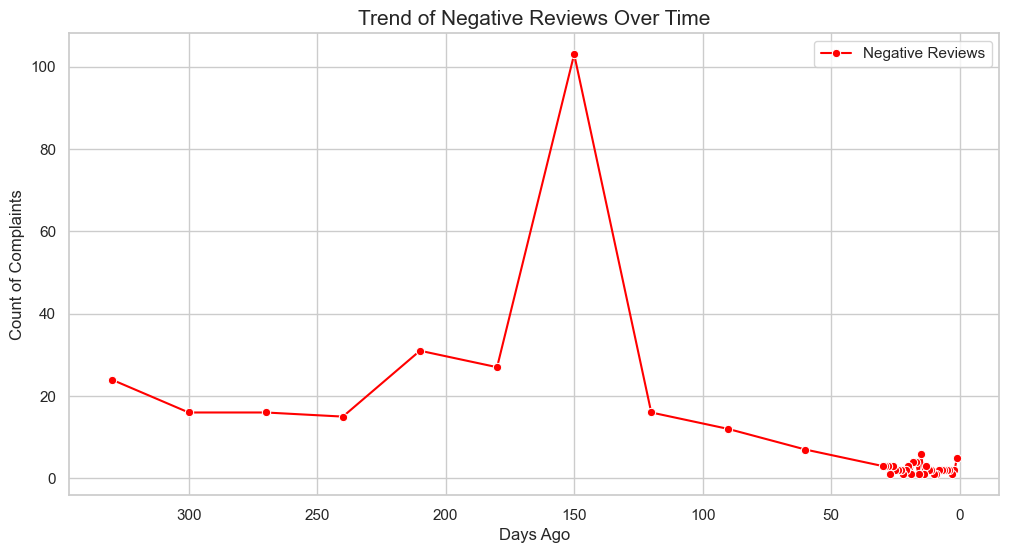

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: CLEAN DATA (Merge similar sentiments) ---
# This fixes the issue of having "Positive", "Pos", "Neg", "Negative" all as separate slices
sentiment_map = {
    'Positive': 'Pos', 'Pos': 'Pos',
    'Negative': 'Neg', 'Neg': 'Neg',
    'Neutral': 'Neu', 'Neu': 'Neu',
    'No Mix': 'Other', 'Mix': 'Other'
}
df_final['sentiment_clean'] = df_final['sentiment'].str.strip().map(sentiment_map).fillna('Other')

# --- STEP 2: PREPARE DATA ---
sns.set_theme(style="whitegrid")
sentiment_counts = df_final['sentiment_clean'].value_counts()
colors = sns.color_palette('pastel')[0:len(sentiment_counts)] # Dynamic colors

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: PIE CHART (With Legend to fix overlap) ---
wedges, texts, autotexts = ax[0].pie(
    sentiment_counts, 
    labels=None,                # <--- Removed labels from slices
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85,           # Pulls percentages toward the edge
    explode=[0.05]*len(sentiment_counts)
)

# Add Legend to the side
ax[0].legend(
    wedges, 
    sentiment_counts.index, 
    title="Sentiments", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1)
)
ax[0].set_title('Sentiment Distribution (%)', fontsize=15, pad=20)

# --- PLOT 2: BAR CHART ---
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=ax[1], palette=colors)
ax[1].set_title('Review Count by Sentiment', fontsize=15)
ax[1].set_xlabel('Sentiment')
ax[1].set_ylabel('Number of Reviews')

plt.tight_layout()
plt.savefig('sentiment_overview_fixed.png')
plt.show()

# --- PLOT 3: TREND LINE ---
plt.figure(figsize=(12, 6))
# Filter for negative reviews and group by days
neg_trend = df_final[df_final['sentiment_clean'] == 'Neg'].groupby('days').size()

if not neg_trend.empty:
    sns.lineplot(x=neg_trend.index, y=neg_trend.values, color='red', marker='o', label='Negative Reviews')
    plt.gca().invert_xaxis() # Show "Older" to "Newer"
    plt.title('Trend of Negative Reviews Over Time', fontsize=15)
    plt.xlabel('Days Ago')
    plt.ylabel('Count of Complaints')
    plt.savefig('sentiment_trend.png')
    plt.show()
else:
    print("No negative reviews found to plot trend.")